### Análise dos resultados do melhor modelo gerado LightBM com Bayes Search

In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from Funcoes_Comuns import avaliar_modelo

### Resultados do LGBM base Unificada Ciências Humanas

In [6]:
# Obter dados
df_enem_lgbm = pd.read_pickle('Bases\\Finais\\enem_censo_2023_full.pkl')

In [7]:
variaveis_alvo = ['NUM_NOTA_MT', 'NUM_NOTA_LC', 'NUM_NOTA_CN', 'NUM_NOTA_CH', 'NUM_NOTA_REDACAO']
grupo_previsao = ['NUM_NOTA_CH']

# separar em treino e teste
X = df_enem_lgbm.drop(columns=variaveis_alvo)
y = df_enem_lgbm[grupo_previsao]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajuste de tipo para MLflow
# Converter colunas inteiras para float
X_train = X_train.astype({col: 'float' for col in X_train.select_dtypes('int').columns})
X_test = X_test.astype({col: 'float' for col in X_test.select_dtypes('int').columns})

categorical_features = X_train.select_dtypes(include=['category']).columns.tolist()

# Criar Eval Set para validação cruzada (15% do conjunto de treino)
X_train_final, X_eval, y_train_final, y_eval = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42
)

In [8]:
# Ajustar as dimensões dos arrays
y_test = y_test.squeeze()
y_train_final = y_train_final.squeeze()
y_eval = y_eval.squeeze()

In [9]:
# Carregar modelo treinado
with open('Modelos\\modelo_lgbm_bayes_censo_enem.pkl', 'rb') as file:
    modelo = joblib.load(file)

# Aplicar o modelo nos dados de teste
y_pred_lgbm = modelo.predict(X_test)

In [10]:
# Aplicar o modelo nos dados de teste
y_pred_lgbm = modelo.predict(X_test)

In [11]:
# Avaliação grupo teste
avaliar_modelo(y_test, y_pred_lgbm, "teste")

MAE (teste): 54.8751
RMSE (teste): 69.5892
R2 (teste): 0.3207


Comparativo entre resultados reais e resultados previstos

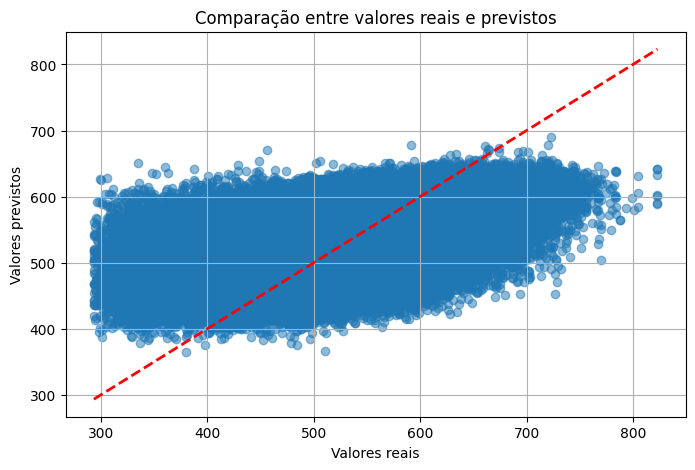

In [14]:
# Criar gráfico de comparação para cada variável alvo
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lgbm, alpha=0.5)
plt.title('Comparação entre valores reais e previstos')
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid()
plt.show()

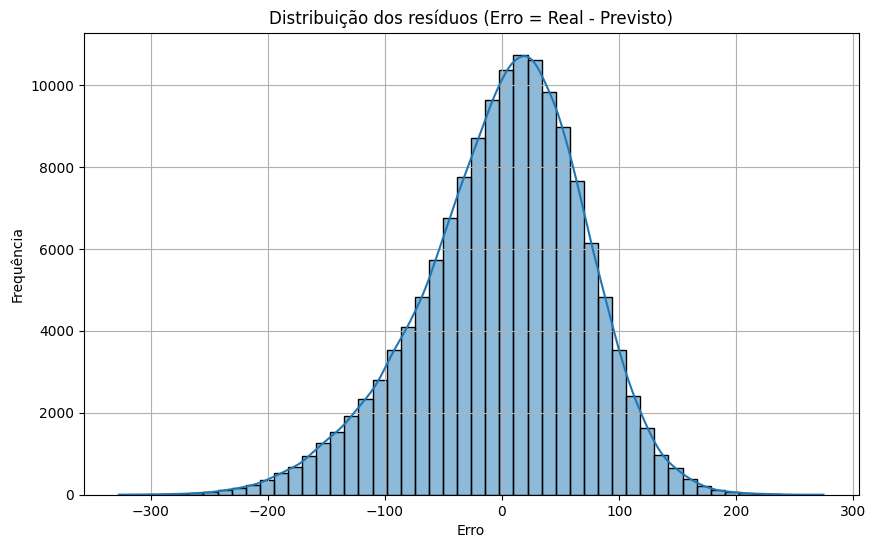

In [15]:
residuals = y_test - y_pred_lgbm
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribuição dos resíduos (Erro = Real - Previsto)")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

#### Análise dos resíduos

- distribuição se mostra próxima a normal centrada em zero
- os erros estão em geral em torno de zero
- modelo está com baixo viés não superestimando ou subestimando as notas

In [16]:
df_resultado = pd.DataFrame({'real': y_test, 'previsto': y_pred_lgbm})
df_resultado['faixa'] = pd.cut(df_resultado['real'], bins=[0, 300, 500, 700, 1000])

# Corrigir o aviso de depreciação com include_groups=False
resultados = df_resultado.groupby('faixa', observed=False).apply(
    lambda x: mean_absolute_error(x['real'], x['previsto']), include_groups=False
)
print(resultados)

faixa
(0, 300]       195.355072
(300, 500]      68.742959
(500, 700]      46.168067
(700, 1000]    127.199270
dtype: float64


In [17]:
# Criar faixas e calcular porcentagem e MAE em um único DataFrame
df_porcentagem = (
    df_resultado
    .assign(Faixa=pd.cut(df_resultado['real'], bins=[0, 300, 500, 700, 1000]))
    .groupby('Faixa', observed=False)
    .agg(
        Amostra=('real', lambda x: round(len(x) / len(df_resultado) * 100, 1)),
        MAE=('real', lambda x: mean_absolute_error(x, df_resultado.loc[x.index, 'previsto']))
    )
    .reset_index()
)

print(df_porcentagem)

         Faixa  Amostra         MAE
0     (0, 300]      0.1  195.355072
1   (300, 500]     34.5   68.742959
2   (500, 700]     64.4   46.168067
3  (700, 1000]      1.0  127.199270


- Maior erro está abaixo de 300
- Depois acima de 700 -> Pode haver uma baixa quantidade de amostrar para valores acima de 700

### Balancear dados

- SMOTE ou subamostragem para equilibrar extremidades
- ponderar erros por faixa
- criar modelos diferentes para faixas diferentes